In [1]:
#Importar librerias
import matplotlib.pyplot as plt
import matplotlib.colors as colors
#import os
#import sys
import numpy as np
import networkx as nx
from networkx.algorithms.approximation import average_clustering
#import community.community_louvain as cl
import pandas as pd
#import pickle

from utils import *

In [2]:
#Importar datos
filename_e = 'celegans_connectome.csv'
df_elegans = pd.read_csv(filename_e)
df_elegans.head()

,Unnamed: 0,Neuron,Target,weight,Neurotransmitter
0,0,ADAL,AIBL,1.0,exc
1,1,ADAL,AIBR,2.0,exc
2,2,ADAL,AVAR,2.0,exc
3,3,ADAL,AVBL,4.0,exc
4,4,ADAL,AVBR,7.0,exc


In [3]:
filename_m = 'email-Eu-core.txt'
df_mails = pd.read_csv(filename_m, sep=' ', header=None)
df_mails.head()

,0,1
0,0,1
1,2,3
2,2,4
3,5,6
4,5,7


In [4]:
G_elegans = nx.from_pandas_edgelist(df_elegans, source='Neuron', target='Target', edge_attr=['weight','Neurotransmitter'], create_using=nx.DiGraph())

In [5]:
G_mails = nx.from_pandas_edgelist(df_mails, source=0, target=1, create_using=nx.DiGraph())

In [6]:
#Generar grafo: componente fuertemente conexa más grande, sin autoenlaces
G_e = G_elegans.copy()
G_e.remove_edges_from(nx.selfloop_edges(G_e))
largest_scc = max(nx.strongly_connected_components(G_e), key=len)
G_e = G_e.subgraph(largest_scc).copy()

In [7]:
G_m = G_mails.copy()
G_m.remove_edges_from(nx.selfloop_edges(G_m))
largest_scc = max(nx.strongly_connected_components(G_m), key=len)
G_m = G_m.subgraph(largest_scc).copy()

In [8]:
def edge_removal_fixed(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            largest_cc = max(nx.strongly_connected_components(G), key=len)
            sizes.append(len(largest_cc) / N)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)

    sizes.append(0)
    return np.array(sizes)

In [9]:
def average_random(G, centrality_dict, n_iter=100):
    curves = [edge_removal_fixed(G, centrality_dict, 'random') for _ in range(n_iter)]
    return np.mean(curves, axis=0)

In [10]:
# calcular centralidades
b_centrality_e = nx.betweenness_centrality(G_e)
d_centrality_e = nx.degree_centrality(G_e)
#o_centrality = dict(G.out_degree())
#i_centrality = dict(G.in_degree())
#p_centrality = nx.pagerank(G)
#c_centrality = nx.closeness_centrality(G)
#e_centrality = nx.eigenvector_centrality(G)

centralities_e = {
    'Intermediación': b_centrality_e,
    'Grado': d_centrality_e,
    #'Grado-Out': o_centrality,
    #'Grado-In': i_centrality,
    #'PageRank': p_centrality,
    #'Cercanía': c_centrality,
    #'Autovector': e_centrality
}

In [11]:
b_centrality_m = nx.betweenness_centrality(G_m)
d_centrality_m = nx.degree_centrality(G_m)
#o_centrality = dict(G.out_degree())
#i_centrality = dict(G.in_degree())
#p_centrality = nx.pagerank(G)
#c_centrality = nx.closeness_centrality(G)
#e_centrality = nx.eigenvector_centrality(G)

centralities_m = {
    'Intermediación': b_centrality_m,
    'Grado': d_centrality_m,
    #'Grado-Out': o_centrality,
    #'Grado-In': i_centrality,
    #'PageRank': p_centrality,
    #'Cercanía': c_centrality,
    #'Autovector': e_centrality
}

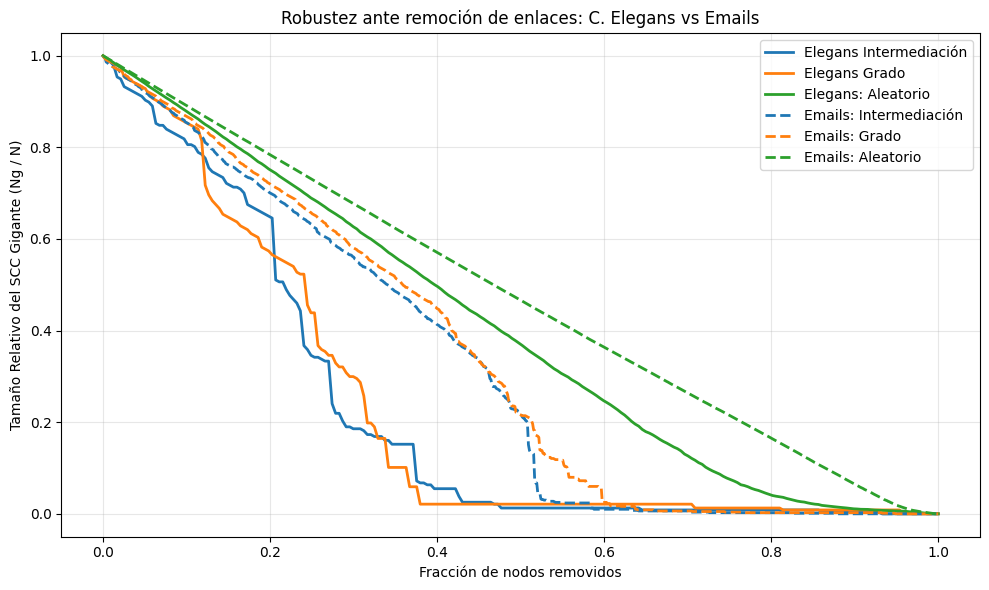

In [12]:
colors = {'Intermediación': 'tab:blue', 'Grado': 'tab:orange', 'random': 'tab:green'}

plt.figure(figsize=(10, 6))

N_e = G_e.number_of_nodes()
x_e = np.arange(N_e + 1) / N_e

curves_e = {}
curves_m = {}

for name, centrality in centralities_e.items():
    curves_e[f'curve_{name}'] = edge_removal_fixed(G_e, centrality, strategy='targeted')
    plt.plot(x_e, curves_e[f'curve_{name}'], label=f'Elegans {name}', color=colors[name], linestyle='-', linewidth=2)

curve_random_e = average_random(G_e, centralities_e['Grado'])
plt.plot(x_e, curve_random_e, label='Elegans: Aleatorio', 
         color=colors['random'], linestyle='-', linewidth=2)

N_m = G_m.number_of_nodes()
x_m = np.arange(N_m + 1) / N_m

for name, centrality in centralities_m.items():
    curves_m[f'curve_{name}'] = edge_removal_fixed(G_m, centrality, strategy='targeted')
    plt.plot(x_m,  curves_m[f'curve_{name}'], label=f'Emails: {name}', 
             color=colors[name], linestyle='--', linewidth=2)

curve_random_m = average_random(G_m, centralities_m['Grado'])
plt.plot(x_m, curve_random_m, label='Emails: Aleatorio', 
         color=colors['random'], linestyle='--', linewidth=2)

plt.xlabel('Fracción de nodos removidos')
plt.ylabel('Tamaño Relativo del SCC Gigante (Ng / N)')
plt.title('Robustez ante remoción de enlaces: C. Elegans vs Emails')

#plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
for name, centrality in centralities_e.items():
    curves_e[f'curve_{name}'] = edge_removal_fixed(G_e, centrality, strategy='targeted')

for name, centrality in centralities_m.items():
    curves_m[f'curve_{name}'] = edge_removal_fixed(G_m, centrality, strategy='targeted')

In [14]:
#Cálculo de área bajo la curva para cada centralidad
areas_e = {name: np.trapezoid(curve, x_e) for name, curve in curves_e.items()}
areas_e['Aleatorio'] = np.trapezoid(curve_random_e, x_e)
areas_e

{'curve_Intermediación': np.float64(0.21956061172532892),
 'curve_Grado': np.float64(0.22536452491587886),
 'Aleatorio': np.float64(0.4035466182413787)}

In [15]:
areas_m = {name: np.trapezoid(curve, x_m) for name, curve in curves_m.items()}
areas_m['Aleatorio'] = np.trapezoid(curve_random_m, x_m)
areas_m

{'curve_Intermediación': np.float64(0.31914024152888687),
 'curve_Grado': np.float64(0.33567537053608126),
 'Aleatorio': np.float64(0.4737145573340322)}

In [16]:
in_deg_e = np.array([d for _, d in G_e.in_degree()])
out_deg_e = np.array([d for _, d in G_e.out_degree()])

In [17]:
print(np.corrcoef(in_deg_e, out_deg_e)[0,1])

0.48674640547313497


In [18]:
in_deg_m = np.array([d for _, d in G_m.in_degree()])
out_deg_m = np.array([d for _, d in G_m.out_degree()])

In [19]:
print(np.corrcoef(in_deg_m, out_deg_m)[0,1])

0.9223323778385025


In [20]:
top_in_e = sorted(G_e.in_degree(), key=lambda x: x[1], reverse=True)[:10]
top_out_e = sorted(G_e.out_degree(), key=lambda x: x[1], reverse=True)[:10]

print("Top in-degree:")
print(top_in_e)

print("\nTop out-degree:")
print(top_out_e)

Top in-degree:
[('AVAL', 50), ('AVAR', 48), ('AVBL', 39), ('AVBR', 37), ('AVEL', 36), ('AVDR', 33), ('AVER', 33), ('AVDL', 27), ('RIAL', 27), ('RIAR', 26)]

Top out-degree:
[('AVAR', 40), ('DVA', 33), ('AVAL', 29), ('PVCL', 29), ('PVCR', 28), ('ADEL', 24), ('RIH', 23), ('HSNR', 23), ('PVR', 22), ('ADER', 20)]


In [21]:
top_in_m = sorted(G_m.in_degree(), key=lambda x: x[1], reverse=True)[:10]
top_out_m = sorted(G_m.out_degree(), key=lambda x: x[1], reverse=True)[:10]

print("Top in-degree:")
print(top_in_m)

print("\nTop out-degree:")
print(top_out_m)

Top in-degree:
[(160, 211), (62, 178), (107, 168), (121, 156), (86, 153), (434, 150), (183, 142), (129, 136), (64, 135), (128, 131)]

Top out-degree:
[(160, 324), (82, 211), (121, 209), (86, 197), (107, 194), (62, 182), (13, 164), (249, 157), (183, 156), (434, 154)]


In [22]:
set_in = set([n for n, _ in top_in_e])
set_out = set([n for n, _ in top_out_e])

print("Intersección:", set_in & set_out)

Intersección: {'AVAL', 'AVAR'}


In [23]:
set_in = set([n for n, _ in top_in_m])
set_out = set([n for n, _ in top_out_m])

print("Intersección:", set_in & set_out)

Intersección: {160, 107, 434, 86, 183, 121, 62}


In [24]:
def directional_asymmetry(G):

    asym = []

    for n in G.nodes():

        kin  = G.in_degree(n)
        kout = G.out_degree(n)

        if kin + kout > 0:

            a = abs(kin-kout)/(kin+kout)

            asym.append(a)

    return asym

In [25]:
asym_mail = directional_asymmetry(G_m)
asym_ce   = directional_asymmetry(G_e)

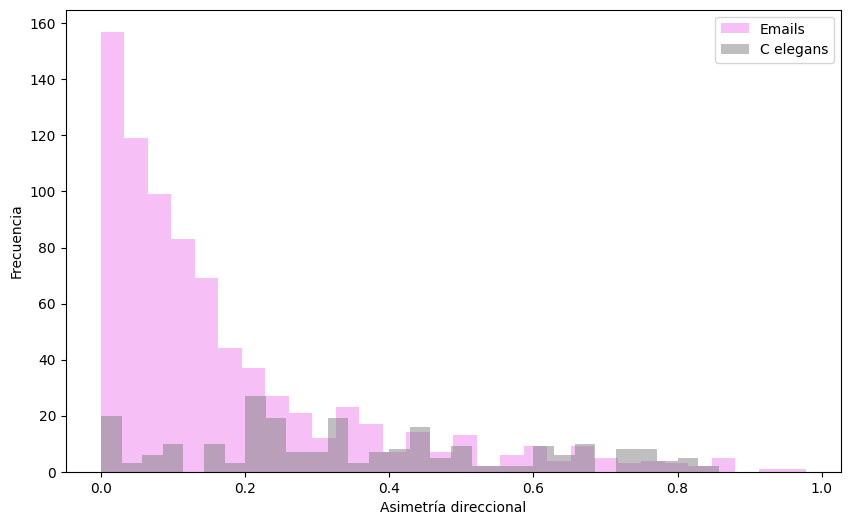

In [26]:
plt.figure(figsize=(10,6))

plt.hist(asym_mail, bins=30, alpha=0.5, label='Emails', color='violet')
plt.hist(asym_ce, bins=30, alpha=0.5, label='C elegans', color='grey')

plt.xlabel('Asimetría direccional')
plt.ylabel('Frecuencia')

plt.legend()
plt.show()

In [27]:
def fragment_size_distribution_normalized(G_original, ranking):

    G = G_original.copy()

    N = G.number_of_nodes()

    all_sizes = []

    for node in ranking:

        G.remove_edges_from(
            list(G.in_edges(node)) +
            list(G.out_edges(node))
        )

        sccs = sorted(
            [
                len(c)/N
                for c in nx.strongly_connected_components(G)
            ],
            reverse=True
        )

        all_sizes.append(sccs)

    return all_sizes

In [28]:
degree_ranking_e = sorted(
    centralities_e['Grado'],
    key=centralities_e['Grado'].get,
    reverse=True
)

In [29]:
dist_e = fragment_size_distribution_normalized(
    G_e,
    degree_ranking_e
)

In [30]:
degree_ranking_m = sorted(
    centralities_m['Grado'],
    key=centralities_m['Grado'].get,
    reverse=True
)

In [31]:
dist_m = fragment_size_distribution_normalized(
    G_m,
    degree_ranking_m
)

In [98]:
def compare_fragment_rankplots(
    dist1,
    dist2,
    N1,
    N2,
    labels=('Emails','C elegans')
):

    checkpoints = [0.1,0.3,0.5,0.7]

    fig, axes = plt.subplots(
        2, 2,
        figsize=(12,8),
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, cp in enumerate(checkpoints):

        idx1 = int(cp*len(dist1))
        idx2 = int(cp*len(dist2))

        sizes1 = sorted(
            [s for s in dist1[idx1] if s > 1/N1],
            reverse=True
        )

        sizes2 = sorted(
            [s for s in dist2[idx2] if s > 1/N2],
            reverse=True
        )

        ax = axes[i]

        ax.plot(
            range(1, len(sizes1)+1),
            sizes1,
            'o-',
            alpha=0.7,
            color = 'violet',
            label=labels[0]
        )

        ax.plot(
            range(1, len(sizes2)+1),
            sizes2,
            'o-',
            alpha=0.7,
            color = 'grey',
            label=labels[1]
        )

        ax.set_title(f'{int(cp*100)}% removido')

        if i in [0,2]:
            ax.set_ylabel('Tamaño SCC normalizado')
        else:
            ax.tick_params(labelleft=False)

        # etiqueta eje x sólo abajo
        if i in [2,3]:
            ax.set_xlabel('Rank SCC')
        else:
            ax.tick_params(labelbottom=False)

        # nombre eje y sólo izquierda

        if i in [0,1]:
            ax.set_ylim(0, 0.95)
        # nombre eje x sólo abajo
        if i in [2,3]:
            ax.set_ylim(0, 0.25)
            ax.set_xlabel('Rank SCC')
        ax.set_xlim(0,25)
        ax.legend()

    plt.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.show()

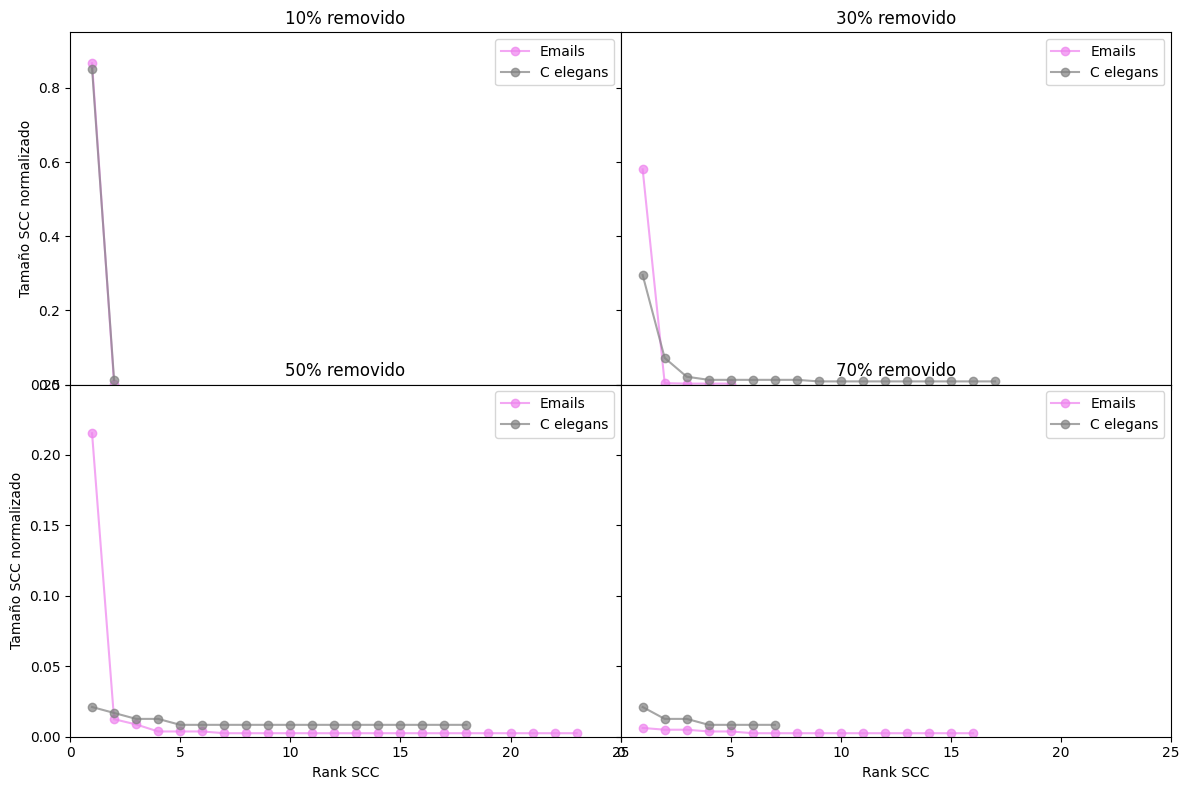

In [99]:
compare_fragment_rankplots(
    dist_m,
    dist_e,
    G_m.number_of_nodes(),
    G_e.number_of_nodes(),
    labels=('Emails','C elegans')
)

In [81]:
for cp in [0.1,0.3,0.5,0.7]:

    idx = int(cp * len(dist_e))

    print(cp, dist_e[idx][0])

0.1 0.8523206751054853
0.3 0.29535864978902954
0.5 0.02109704641350211
0.7 0.02109704641350211


# strong vs weak

In [36]:
def strong_vs_weak_curve(G_original, centrality_dict):

    G = G_original.copy()
    N = G.number_of_nodes()

    ordered = sorted(
        centrality_dict,
        key=centrality_dict.get,
        reverse=True
    )

    strong = []
    weak = []
    x = []

    for i,node in enumerate(ordered):

        if node in G:
            G.remove_edges_from(
                list(G.in_edges(node)) +
                list(G.out_edges(node))
            )

        scc = max(
            nx.strongly_connected_components(G),
            key=len
        )

        wcc = max(
            nx.weakly_connected_components(G),
            key=len
        )

        strong.append(len(scc)/N)
        weak.append(len(wcc)/N)

        x.append(i/N)

    return x,strong,weak

In [37]:
x, s, w = strong_vs_weak_curve(
    G,
    centralities['Grado']
)

NameError: name 'G' is not defined

In [ ]:
plt.plot(x, s, label='Strong')
plt.plot(x, w, label='Weak')

plt.xlabel('Fracción de nodos atacados')
plt.ylabel('Componente gigante normalizada')

plt.legend()
plt.show()

# analisis de segunda, tercera y cuarta

In [ ]:
#Análisis de robustez de segunda componente fuertemente conexa más grande
def edge_removal_fixed_second_largest(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    x = np.arange(N + 1) / N
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
            if len(sccs) > 1:
                second_largest_cc = sccs[1]
                sizes.append(len(second_largest_cc) / N)
            else:
                sizes.append(0)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)

    sizes.append(0)
    return np.array(sizes)

N = G.number_of_nodes()
x = np.arange(N + 1) / N

curves_second = {}
plt.figure(figsize=(10, 6))

for name, centrality in centralities.items():
    curves_second[f'curve_{name}'] = edge_removal_fixed_second_largest(G, centrality, strategy='targeted')

    plt.plot(x, curves_second[f'curve_{name}'], label=f'{name}', marker='*', linewidth=0.25)

plt.xlabel('Fracción de nodos procesados')
plt.ylabel('Tamaño Relativo del SCC Segunda Más Grande (Nscc2 / N)')
plt.title('Robustez de la Segunda Componente Fuertemente Conexa Más Grande')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
#Análisis de robustez de tercera componente fuertemente conexa más grande
def edge_removal_fixed_third_largest(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
            if len(sccs) > 2:
                third_largest_cc = sccs[2]
                sizes.append(len(third_largest_cc) / N)
            else:
                sizes.append(0)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)
    sizes.append(0)
    return np.array(sizes)
curves_third = {}
plt.figure(figsize=(10, 6))
for name, centrality in centralities.items():
    curves_third[f'curve_{name}'] = edge_removal_fixed_third_largest(G, centrality, strategy='targeted')
    plt.plot(x, curves_third[f'curve_{name}'], label=f'{name}', marker='*', linewidth=0.25)
#curve_random_third = average_random(G, centrality, n_iter=20)
#plt.plot(x, curve_random_third, label='Aleatorio', linestyle='--')
plt.xlabel('Fracción de nodos procesados')
plt.ylabel('Tamaño Relativo del SCC Tercera Más Grande (Nscc3 / N)')
plt.title('Robustez de la Tercera Componente Fuertemente Conexa Más Grande')
plt.legend()

In [ ]:
##Análisis de robustez de cuarta componente fuertemente conexa más grande
def edge_removal_fixed_fourth_largest(G, centrality_dict, strategy='targeted'):
    G = G.copy()
    N = G.number_of_nodes()
    sizes = []

    nodes = list(G.nodes())

    if strategy == 'targeted':
        nodes = sorted(nodes, key=lambda x: centrality_dict[x], reverse=True)
    elif strategy == 'random':
        np.random.shuffle(nodes)

    for node in nodes:
        if G.number_of_edges() > 0:
            sccs = sorted(nx.strongly_connected_components(G), key=len, reverse=True)
            if len(sccs) > 3:
                fourth_largest_cc = sccs[3]
                sizes.append(len(fourth_largest_cc) / N)
            else:
                sizes.append(0)

            G.remove_edges_from(list(G.in_edges(node)) + list(G.out_edges(node)))
        else:
            sizes.append(0)
    sizes.append(0)
    return np.array(sizes)
curves_fourth = {}
plt.figure(figsize=(10, 6))
for name, centrality in centralities.items():
    curves_fourth[f'curve_{name}'] = edge_removal_fixed_fourth_largest(G, centrality, strategy='targeted')
    plt.plot(x, curves_fourth[f'curve_{name}'], label=f'{name}', marker='*', linewidth=0.25)
#curve_random_fourth = average_random(G, centrality, n_iter=20)
#plt.plot(x, curve_random_fourth, label='Aleatorio', linestyle='--')    
plt.xlabel('Fracción de nodos procesados')
plt.ylabel('Tamaño Relativo del SCC Cuarta Más Grande (Nscc4 / N)')
plt.title('Robustez de la Cuarta Componente Fuertemente Conexa Más Grande')
plt.legend()



In [ ]:
#Código para armar una tabla por tipo de centralidad. En filas tiene 100 valores de fracción de nodos procesados, y en las columnas tiene el tamaño de la componente fiertemente coneexa más grande, la segunda, la tercera y la cuarta.
table_data = []
for i in range(len(x)//10):
    row = [x[i*10]]
    for name in centralities.keys():
        row.append(curves[f'curve_{name}'][i*10])
        row.append(curves_second[f'curve_{name}'][i*10])
        row.append(curves_third[f'curve_{name}'][i*10])
        row.append(curves_fourth[f'curve_{name}'][i*10])
    table_data.append(row)
columns = ['Fracción de nodos procesados']
for name in centralities.keys():
    columns.extend([f'{name} - SCC1', f'{name} - SCC2', f'{name} - SCC3', f'{name} - SCC4'])
df_results = pd.DataFrame(table_data, columns=columns)
print(df_results.head(50))


In [ ]:
def robustness_fragmentation(
    G,
    centrality=None,
    strategy="targeted",   # "targeted" o "random"
    component_type="strong"  # "strong" o "weak"
):
    G = G.copy()
    N = G.number_of_nodes()
    
    nodes = list(G.nodes())
    
    # Orden de ataque
    if strategy == "targeted":
        assert centrality is not None, "Falta centralidad"
        nodes = sorted(nodes, key=lambda x: centrality[x], reverse=True)
    elif strategy == "random":
        np.random.shuffle(nodes)
    
    # Resultados
    S1 = []
    S2 = []
    mean_rest = []
    n_components = []
    all_sizes = []

    for i, node in enumerate(nodes):
        
        # Elegir tipo de componente
        if component_type == "strong":
            comps = list(nx.strongly_connected_components(G))
        elif component_type == "weak":
            comps = list(nx.weakly_connected_components(G))
        else:
            raise ValueError("component_type debe ser 'strong' o 'weak'")
        
        sizes = sorted([len(c) for c in comps], reverse=True)
        all_sizes.append(sizes)
        
        # Métricas
        s1 = sizes[0] if len(sizes) > 0 else 0
        s2 = sizes[1] if len(sizes) > 1 else 0
        
        S1.append(s1 / N)
        S2.append(s2 / N)
        n_components.append(len(sizes))
        
        if len(sizes) > 1:
            mean_rest.append(np.mean(sizes[1:]) / N)
        else:
            mean_rest.append(0)
        
        # remover nodo
        G.remove_node(node)
    
    f = np.arange(len(S1)) / N  # fracción removida
    
    return {
        "f": f,
        "S1": np.array(S1),
        "S2": np.array(S2),
        "mean_rest": np.array(mean_rest),
        "n_components": np.array(n_components),
        "all_sizes": all_sizes
    }

In [ ]:
deg_cent = nx.degree_centrality(G)
bet_cent = nx.betweenness_centrality(G)
pagerank = nx.pagerank(G)

In [ ]:
res_deg_strong = robustness_fragmentation(
    G,
    centrality=deg_cent,
    strategy="targeted",
    component_type="strong"
)

In [ ]:
res_deg_weak = robustness_fragmentation(
    G,
    centrality=deg_cent,
    strategy="targeted",
    component_type="weak"
)

In [ ]:
res_rand_weak = robustness_fragmentation(
    G,
    strategy="random",
    component_type="weak"
)

In [ ]:
def plot_S1_S2(res, title=""):
    plt.figure(figsize=(6,4))
    plt.plot(res["f"], res["S1"], label="S1 (GCC)")
    plt.plot(res["f"], res["S2"], label="S2")
    plt.xlabel("Fracción removida")
    plt.ylabel("Tamaño relativo")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
plot_S1_S2(res_deg_strong, "Degree attack (SCC)")
plot_S1_S2(res_deg_weak, "Degree attack (WCC)")

In [ ]:
def plot_components(res, title=""):
    plt.figure(figsize=(6,4))
    plt.plot(res["f"], res["n_components"])
    plt.xlabel("Fracción removida")
    plt.ylabel("Número de componentes")
    plt.title(title)
    plt.grid()
    plt.show()

In [ ]:
plot_components(res_deg_strong, "Degree attack (SCC)")
plot_components(res_deg_weak, "Degree attack (WCC)")

In [ ]:
def plot_mean_rest(res, title=""):
    plt.figure(figsize=(6,4))
    plt.plot(res["f"], res["mean_rest"])
    plt.xlabel("Fracción removida")
    plt.ylabel("Tamaño medio (sin GCC)")
    plt.title(title)
    plt.grid()
    plt.show()

In [ ]:
plot_mean_rest(res_deg_strong, "Degree attack (SCC)")
plot_mean_rest(res_deg_weak, "Degree attack (WCC)")

In [ ]:
def plot_histogram_step(res, step):
    sizes = res["all_sizes"][step]
    
    plt.figure(figsize=(5,3))
    plt.hist(sizes, bins=20)
    plt.xlabel("Tamaño de componente")
    plt.ylabel("Frecuencia")
    plt.title(f"Distribución en paso {step}")
    plt.show()

In [ ]:
plot_histogram_step(res_deg_strong, 20)
plot_histogram_step(res_deg_weak, 20)